# Cross-Validation — Getting a Trustworthy Score

## The Problem with a Single Train/Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)   # 0.91
```

This score depends entirely on which 20% ended up in the test set.
Change `random_state=42` to `random_state=7` — the score changes.
You have no idea if 0.91 is typical or lucky.

**Cross-validation** solves this: train and evaluate k times on different splits,
then report mean ± std. That's a real estimate.

## What We Cover

| Section | Topic |
|---|---|
| 1 | K-Fold cross-validation — the standard |
| 2 | Stratified K-Fold — for imbalanced classes |
| 3 | Leave-One-Out, Repeated K-Fold, Time Series Split |
| 4 | Cross-validating pipelines (no leakage) |
| 5 | Choosing k: bias-variance of CV itself |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_curve, auc, mean_squared_error,
                              mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 6. Cross-Validation

**The problem with a single train/test split:**  
You might get lucky or unlucky with which data ends up in the test set.

**Cross-validation** solves this by rotating through multiple splits:

```
k-fold (k=5):
  Fold 1:  [Test ] [Train] [Train] [Train] [Train]
  Fold 2:  [Train] [Test ] [Train] [Train] [Train]
  Fold 3:  [Train] [Train] [Test ] [Train] [Train]
  Fold 4:  [Train] [Train] [Train] [Test ] [Train]
  Fold 5:  [Train] [Train] [Train] [Train] [Test ]
  
  Final score = mean of 5 test scores
```

Result: much more reliable estimate of true model performance.

=== Cross-Validation vs Single Split ===
Single split (20 random seeds):
  Mean: 0.8885  Std: 0.0305
  Range: [0.8400, 0.9400]

5-Fold Cross-Validation:
  Scores: [0.9  0.89 0.9  0.88 0.87]
  Mean: 0.8880  Std: 0.0117
  Final report: 0.888 ± 0.012


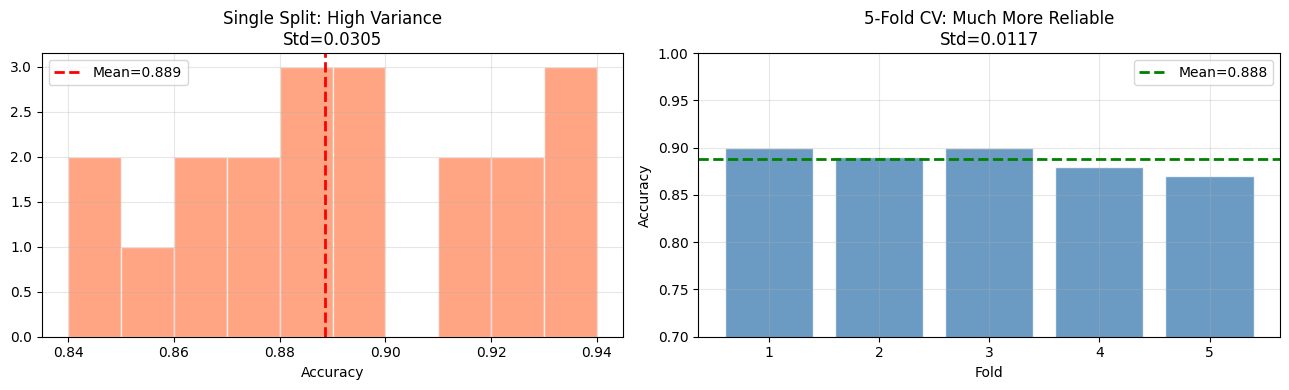

In [2]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

# Create a dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# Single train/test split (unreliable)
single_scores = []
for seed in range(20):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    X_tr, X_te = X[idx[:400]], X[idx[400:]]
    y_tr, y_te = y[idx[:400]], y[idx[400:]]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    single_scores.append(model.score(X_te, y_te))

# 5-fold cross-validation
model_cv = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(model_cv, X, y, cv=5)

print("=== Cross-Validation vs Single Split ===")
print("Single split (20 random seeds):")
print(f"  Mean: {np.mean(single_scores):.4f}  Std: {np.std(single_scores):.4f}")
print(f"  Range: [{min(single_scores):.4f}, {max(single_scores):.4f}]")
print()
print("5-Fold Cross-Validation:")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")
print(f"  Final report: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(single_scores, bins=10, color='coral', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(single_scores), color='red', lw=2, linestyle='--',
                label=f'Mean={np.mean(single_scores):.3f}')
axes[0].set_title(f'Single Split: High Variance\nStd={np.std(single_scores):.4f}')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

axes[1].bar(range(1,6), cv_scores, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axhline(cv_scores.mean(), color='green', lw=2, linestyle='--',
                label=f'Mean={cv_scores.mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'5-Fold CV: Much More Reliable\nStd={cv_scores.std():.4f}')
axes[1].set_ylim(0.7, 1.0)
axes[1].legend()
axes[1].set_xticks(range(1,6))

plt.tight_layout()
plt.show()

---
## Summary — Cross-Validation

### The Patterns

```python
from sklearn.model_selection import (
    cross_val_score, cross_validate,
    KFold, StratifiedKFold, RepeatedKFold,
    TimeSeriesSplit, LeaveOneOut,
)

# Standard — 5-fold is the default
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"{scores.mean():.4f} +/- {scores.std():.4f}")

# Imbalanced classification — always use Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

# Multiple metrics at once
results = cross_validate(model, X, y, cv=5,
                         scoring=['r2','neg_root_mean_squared_error'],
                         return_train_score=True)

# Time series — never shuffle
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X, y, cv=tscv)

# Full pipeline (no leakage — scaler fits inside each fold)
pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
cross_val_score(pipe, X, y, cv=5)
```

### Choosing k

| k | Bias | Variance | Cost | Use when |
|---|---|---|---|---|
| 5 | Slightly higher | Lower | Fast | Default |
| 10 | Lower | Slightly higher | 2x slower | Smaller datasets |
| LOO | Minimal | High | Very slow | Tiny datasets (<100) |
| Repeated 5x2 | Low | Low | 10x slower | Need very reliable estimate |

### The Non-Negotiable Rule

**Always CV a Pipeline, never raw features.**
Fitting a scaler on all folds and then testing = data leakage = inflated scores.

### Next: `bias_variance_tradeoff.ipynb`
Understanding *why* CV scores vary — and what to do about it.
